## Trabajo Práctico: Redes Neuronales
El objetivo de este trabajo es desarrollar y evaluar modelos basados en redes neuronales,
incorporando técnicas de ablación para entender el impacto de diversas modificaciones en
el proceso de entrenamiento y en la capacidad de generalización del modelo. No se permite
usar librerías de machine learning como scikit-learn o PyTorch, a menos que sea pedido
explícitamente en el enunciado del ejercicio.

### 1. Análisis y Preprocesamiento de Datos
- El dataset que vamos a utilizar es similar a MNIST pero con caracteres japoneses.
- Son imágenes de 28 × 28 con 49 clases posibles.
- Examinar el dataset y visualizar al menos 3 imágenes. 
- Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.
- Dividir todos los valores por 255, para que el máximo sea 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import time
sys.path.append('src/')
from preprocessing import *
from plots import *
from visualization import *
from neural_network import *
from improved_neural_network import *
from experiment import *


In [2]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")

print("Forma de X_images:", X_images.shape)
print("Forma de y_images:", y_images.shape)
print("Número de clases únicas:", len(np.unique(y_images)))

Forma de X_images: (5000, 784)
Forma de y_images: (5000,)
Número de clases únicas: 49


1. Una visión clara de la distribución de clases para detectar posibles desbalances
2. Estadísticas sobre los valores de píxeles para entender las propiedades generales de las imágenes
3. Imágenes "promedio" de cada clase para visualizar sus características distintivas
4. Un análisis de complejidad por clase para ver cuáles pueden ser más difíciles de clasificar
5. Múltiples ejemplos de cada clase para comprender mejor la variabilidad dentro de cada categoría

In [3]:
# plot_class_distribution(y_images)
# analyze_image_statistics(X_images)
# plot_class_averages(X_images, y_images, num_classes=15)  # Mostrar las primeras 15 clases
# analyze_image_complexity(X_images, y_images)
# plot_examples_by_class(X_images, y_images, examples_per_class=5)

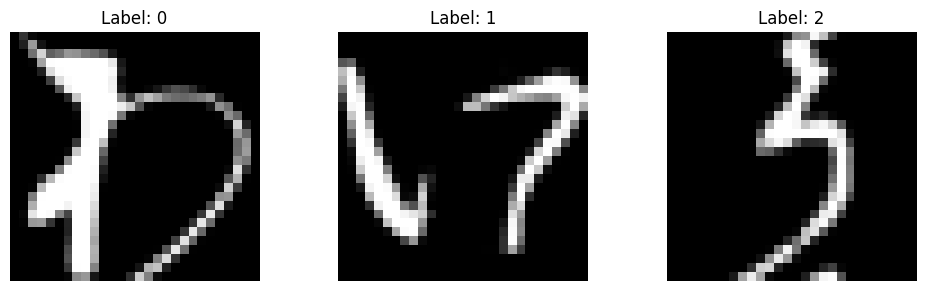

In [4]:
unique_labels = np.unique(y_images)
selected_images = []
selected_labels = []

for label in unique_labels:
    idx = np.where(y_images == label)[0][0]
    selected_images.append(X_images[idx].reshape(28, 28))
    selected_labels.append(label)
    if len(selected_images) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(selected_images[i], cmap='gray')
    ax.set_title(f"Label: {selected_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

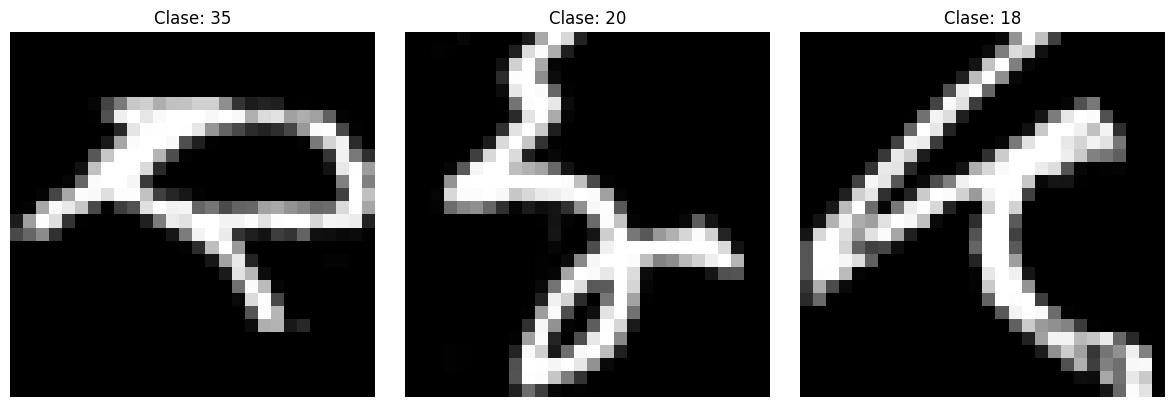

In [5]:
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    idx = np.random.randint(0, len(X_images))
    img = X_images[idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Clase: {y_images[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X_images / 255.0 , y_images, train_ratio=0.8 * 0.8, val_ratio=0.8 * 0.2, test_ratio=0.2, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Rango de valores en X_train: [{X_train.min()}, {X_train.max()}]")

X_train: (3197, 784), y_train: (3197,)
X_val: (802, 784), y_val: (802,)
X_test: (1001, 784), y_test: (1001,)
Rango de valores en X_train: [0.0, 1.0]


### 2. Implementación y Entrenamiento de una Red Neuronal Básica
- Implementar una red neuronal con L capas ocultas cada con M (l) nodos confunción de activación ReLU (en las capas ocultas) y activación softmax para la capa de salida.
- Implementar un algoritmo para entrenar dicha red, mediante backpropagation y gradiente descendiente estándar, utilizando como función de costo la cross-entropy. 
NOTA: El algoritmo backpropagation debe sera adaptado para el caso de clasificación multi-clase con función de activación softmax para la capa de salida y función de costo cross-entropy.
- Entrenar una red neuronal con 2 capas ocultas, con 100 y 80 nodos respectivamente, y graficar la evolución de la función de costo (cross-entropy) sobre los conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a este modelo M0.
Reportar las siguientes métricas de performance, sobre los conjuntos de entrenamiento y validación, para el modelo base entrenado:
    - Accuracy
    - Cross-Entropy 
    - Matriz de Confusión

In [ ]:
# Display some examples from the dataset
visualize_samples(X_train, y_train, num_samples=5, num_classes=10)

In [ ]:

# Create a neural network with 2 hidden layers (100 and 80 nodes)
input_size = X_train.shape[1]  # 784 for 28x28 images
output_size = len(np.unique(y_train))  # Number of classes (49)
layer_sizes = [input_size, 100, 80, output_size]

# Initialize the model (Model M0)
model_M0 = NeuralNetwork(layer_sizes, learning_rate=0.01)

# Train the model
history_M0 = model_M0.train(X_train, y_train, X_val, y_val, epochs=2500)

# Plot learning curves
plot_learning_curves(history_M0)


In [ ]:

# Evaluate the model on training and validation sets
train_pred = model_M0.forward(X_train)
val_pred = model_M0.forward(X_val)

train_loss = model_M0.cross_entropy_loss(y_train, train_pred)
val_loss = model_M0.cross_entropy_loss(y_val, val_pred)

train_accuracy = model_M0.accuracy(y_train, train_pred)
val_accuracy = model_M0.accuracy(y_val, val_pred)

print(f"Performance Metrics for Model M0:")
print(f"Training Set - Accuracy: {train_accuracy:.4f}, Cross-Entropy: {train_loss:.4f}")
print(f"Validation Set - Accuracy: {val_accuracy:.4f}, Cross-Entropy: {val_loss:.4f}")


In [ ]:
# Compute and plot confusion matrix for validation set
conf_matrix = model_M0.confusion_matrix(y_val, val_pred)
plot_confusion_matrix(conf_matrix)

# Since the full confusion matrix might be too large (49x49), 
# let's also look at a subset of classes
plot_confusion_matrix(conf_matrix, class_subset=list(range(10)))  # First 10 classes

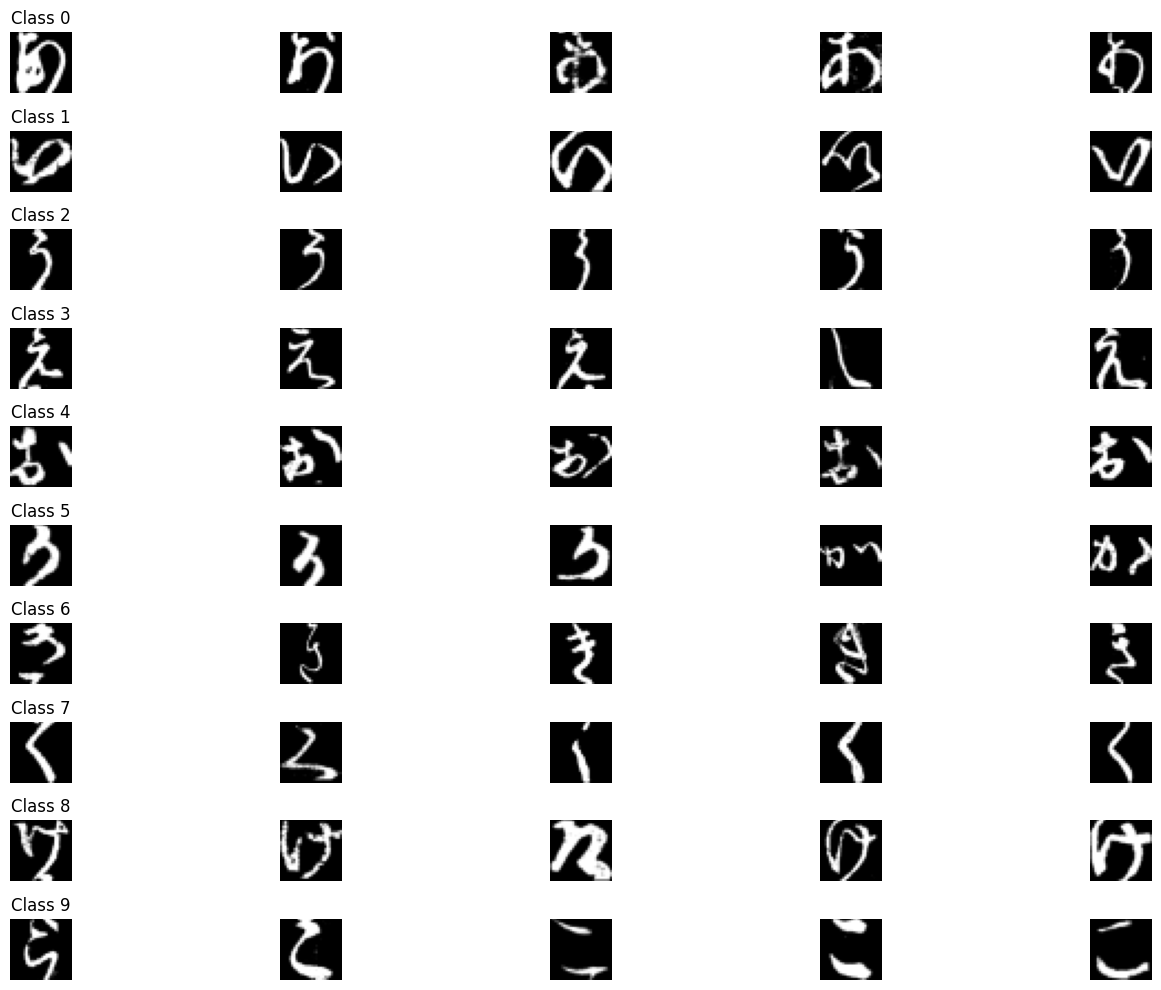

Epoch: [=================================================>] 100% - train_loss: 0.5838 - train_acc: 0.8855 - val_loss: 1.7121 - val_acc: 0.6060

Training completed in 781.59 seconds
Best epoch: 4306
Final train loss: 0.5838, train accuracy: 0.8855
Final val loss: 1.7121, val accuracy: 0.6060
Best val loss: 1.7059, best val accuracy: 0.5973


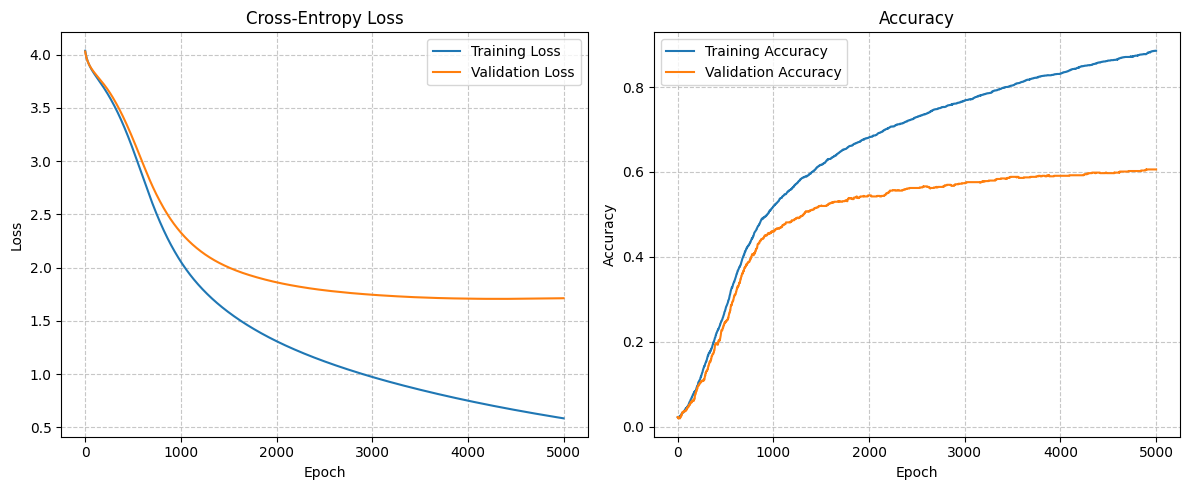

Performance Metrics for Model M0:
Training Set - Accuracy: 0.8855, Cross-Entropy: 0.5838
Validation Set - Accuracy: 0.6060, Cross-Entropy: 1.7121


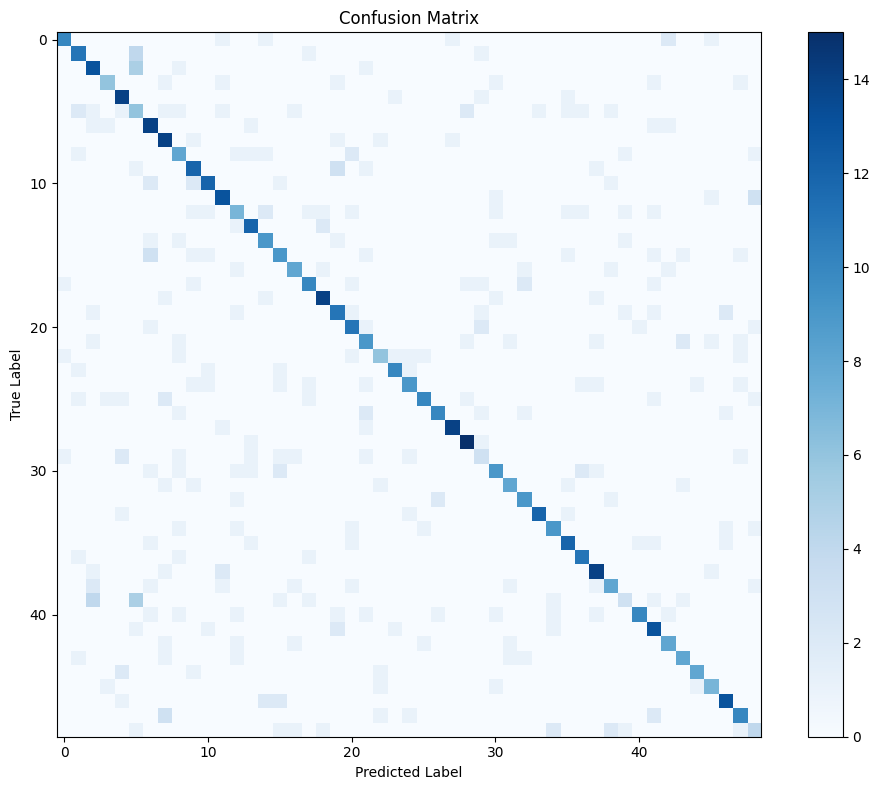

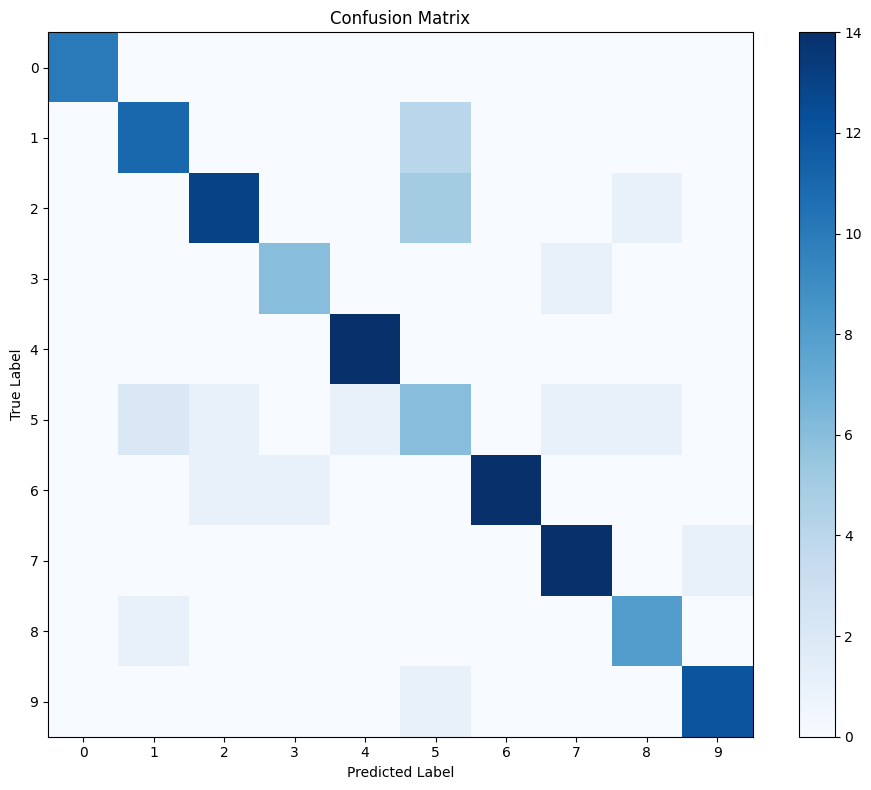

In [7]:
# Display some examples from the dataset
visualize_samples(X_train, y_train, num_samples=5, num_classes=10)

# Create a neural network with 2 hidden layers (100 and 80 nodes)
input_size = X_train.shape[1]  # 784 for 28x28 images
output_size = len(np.unique(y_train))  # Number of classes (49)
layer_sizes = [input_size, 100, 80, output_size]

# Initialize the model (Model M0)
model_M0 = NeuralNetwork(layer_sizes, learning_rate=0.01)

# Train the model
history_M0 = model_M0.train(X_train, y_train, X_val, y_val, epochs=5000)

# Plot learning curves
plot_learning_curves(history_M0)

# Evaluate the model on training and validation sets
train_pred = model_M0.forward(X_train)
val_pred = model_M0.forward(X_val)

train_loss = model_M0.cross_entropy_loss(y_train, train_pred)
val_loss = model_M0.cross_entropy_loss(y_val, val_pred)

train_accuracy = model_M0.accuracy(y_train, train_pred)
val_accuracy = model_M0.accuracy(y_val, val_pred)

print(f"Performance Metrics for Model M0:")
print(f"Training Set - Accuracy: {train_accuracy:.4f}, Cross-Entropy: {train_loss:.4f}")
print(f"Validation Set - Accuracy: {val_accuracy:.4f}, Cross-Entropy: {val_loss:.4f}")

# Compute and plot confusion matrix for validation set
conf_matrix = model_M0.confusion_matrix(y_val, val_pred)
plot_confusion_matrix(conf_matrix)

# Since the full confusion matrix might be too large (49x49), 
# let's also look at a subset of classes
plot_confusion_matrix(conf_matrix, class_subset=list(range(10)))  # First 10 classes

### 3. Implementación y Entrenamiento de una Red Neuronal Avanzada
- Implementar las siguientes mejoras al algoritmo de entrenamiento, y para cada una reportar el efecto observado sobre el tiempo de entrenamiento y la performance del modelo resultante.
    - Rate scheduling lineal (con saturación) y exponencial.
    - Mini-batch stochastic gradient descent.
    - Optimizador ADAM.
    - Regularización L2.
    - Regularización mediante early stopping.
    - OPCIONAL: Regularización mediante dropout.
    - OPCIONAL: batch normalization.
- Explorar cambios en la arquitectura de la red (es decir, la cantidad de capas ocultas y unidades ocultas por capa), y los hiperparámetros (cada uno de los items en la lista anterior tiene una serie de parámetros que podemos variar), y determinar la configuración que funcione mejor (menor error de validación).
Llamaremos a este modelo M1.

In [8]:
# Setup configuration for experiments
input_size = X_train.shape[1]  # 784 for 28x28 images
output_size = len(np.unique(y_train))  # Number of classes (49)
layer_sizes = [input_size, 100, 80, output_size]  # Same architecture as M0

In [ ]:
# Define experiments to run
experiments = [
    # Baseline model (SGD without any improvements)
    {
        'name': 'Baseline (SGD)',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,  # Full batch
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },
    
    # Rate scheduling (Linear)
    {
        'name': 'Linear Rate Scheduling',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,
        'optimizer': 'sgd',
        'lr_schedule': 'linear',
        'early_stopping_patience': None
    },
    
    # Rate scheduling (Exponential)
    {
        'name': 'Exponential Rate Scheduling',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': None,
        'optimizer': 'sgd',
        'lr_schedule': 'exponential',
        'early_stopping_patience': None
    },
    
    # Mini-batch SGD
    {
        'name': 'Mini-batch SGD',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,  # Mini-batch size
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },
    
    # Adam optimizer
    {
        'name': 'ADAM Optimizer',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,  # Mini-batch size (Adam works better with mini-batches)
        'optimizer': 'adam',
        'lr_schedule': None,
        'early_stopping_patience': None
    },
    
    # L2 Regularization
    {
        'name': 'L2 Regularization',
        'learning_rate': 0.001,
        'l2_lambda': 0.001,  # L2 regularization strength
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },
    
    # Early Stopping
    {
        'name': 'Early Stopping',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'epochs': 4000,  # More epochs, but we'll stop early
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': 10  # Stop if no improvement for 10 epochs
    },
    
    # Dropout (optional)
    {
        'name': 'Dropout',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.2,  # 20% dropout rate
        'use_batch_norm': False,
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },
    
    # Batch Normalization (optional)
    {
        'name': 'Batch Normalization',
        'learning_rate': 0.001,
        'l2_lambda': 0.0,
        'dropout_rate': 0.0,
        'use_batch_norm': True,  # Enable batch normalization
        'epochs': 2000,
        'batch_size': 64,
        'optimizer': 'sgd',
        'lr_schedule': None,
        'early_stopping_patience': None
    },
    
    # Combined improvements (find optimal configuration)
    {
        'name': 'Combined Improvements',
        'learning_rate': 0.001,
        'l2_lambda': 0.0005,  # Moderate L2 regularization
        'dropout_rate': 0.2,   # Moderate dropout
        'use_batch_norm': True,  # Use batch normalization
        'epochs': 4000,
        'batch_size': 64,
        'optimizer': 'adam',   # Adam optimizer
        'lr_schedule': 'exponential',  # Learning rate scheduling
        'early_stopping_patience': 15  # Early stopping
    }
]



Running experiment: Baseline (SGD)
Epoch: [=================================================>] 100% - train_loss: 3.6054 - train_acc: 0.1286 - val_loss: 3.6629 - val_acc: 0.1147 - lr: 0.0010

Training completed in 294.07 seconds
Best epoch: 2000
Final train loss: 3.6054, train accuracy: 0.1286
Final val loss: 3.6629, val accuracy: 0.1147
Best val loss: 3.6629, best val accuracy: 0.1147

Results for Baseline (SGD):
Training time: 294.07 seconds
Final train loss: 3.6054, train accuracy: 0.1286
Final val loss: 3.6629, val accuracy: 0.1147

Running experiment: Linear Rate Scheduling
Epoch: [=================================================>] 100% - train_loss: 3.7431 - train_acc: 0.0773 - val_loss: 3.7816 - val_acc: 0.0499 - lr: 0.0005

Training completed in 293.00 seconds
Best epoch: 2000
Final train loss: 3.7431, train accuracy: 0.0773
Final val loss: 3.7816, val accuracy: 0.0499
Best val loss: 3.7816, best val accuracy: 0.0499

Results for Linear Rate Scheduling:
Training time: 293.00 

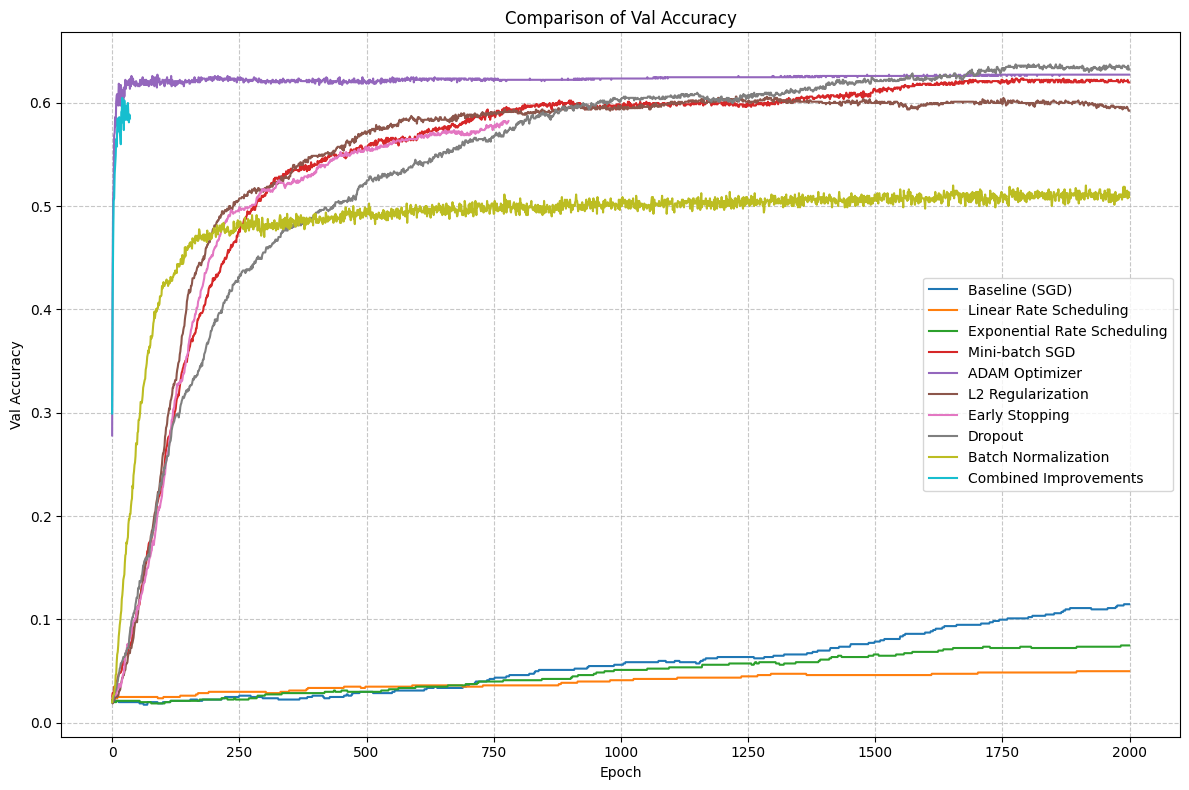

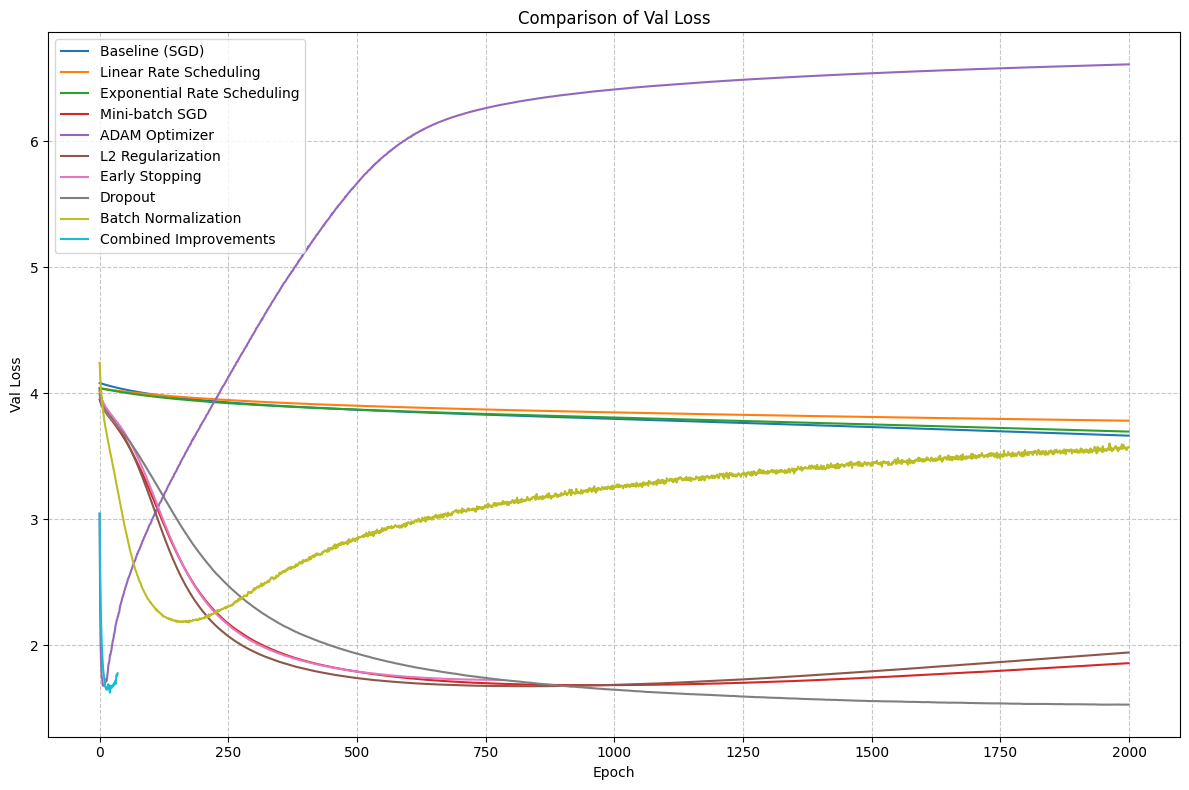

In [ ]:
# Run all experiments
results = run_experiments(X_train, y_train, X_val, y_val, ImprovedNeuralNetwork, layer_sizes, experiments)

# Plot learning curves for all experiments
plot_experiment_results(results, metric='val_accuracy')
plot_experiment_results(results, metric='val_loss')


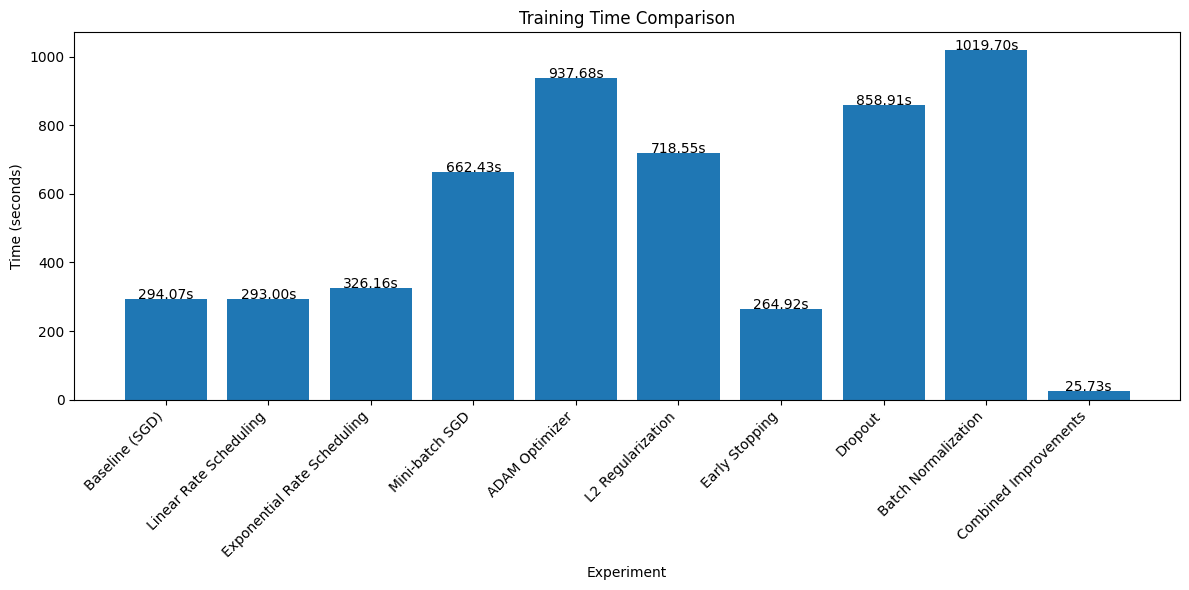

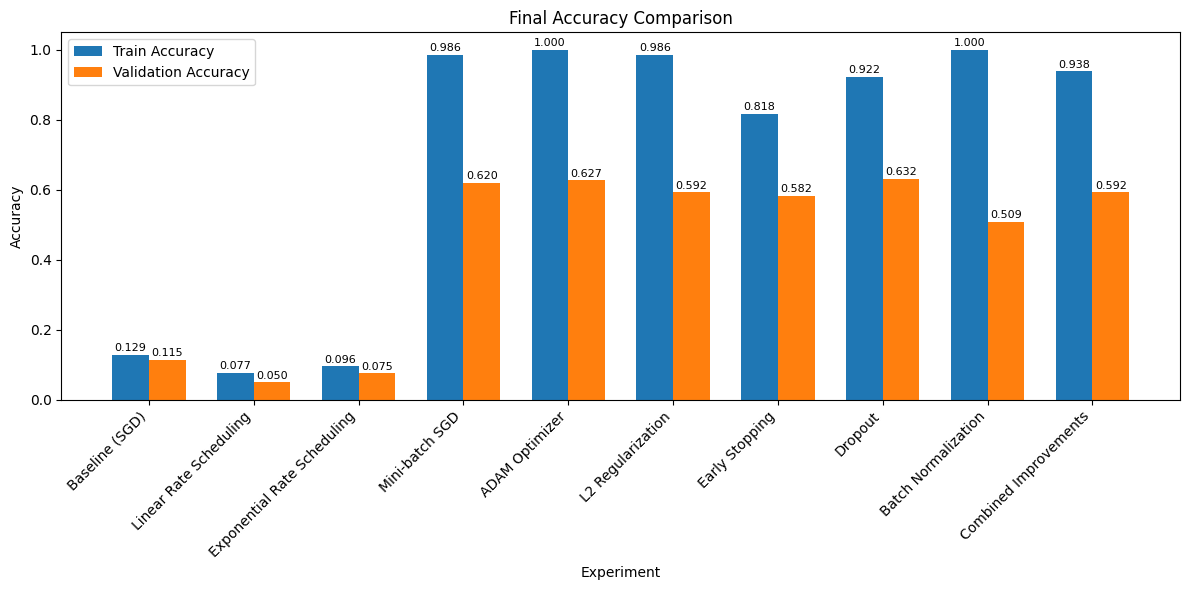

In [11]:

# Compare training times
compare_training_times(results)

# Compare final metrics
compare_final_metrics(results)


In [12]:

# Find the best model based on validation accuracy
best_result = max(results, key=lambda x: x['final_val_accuracy'])
print(f"\nBest model: {best_result['name']}")
print(f"Validation accuracy: {best_result['final_val_accuracy']:.4f}")

# Let's explore different architectures with the best configuration
print("\nExploring different architectures with the best configuration...")



Best model: Dropout
Validation accuracy: 0.6322

Exploring different architectures with the best configuration...


In [13]:

# Define different architectures to try
architectures = [
    {
        'name': 'Single Hidden Layer (200)',
        'layer_sizes': [input_size, 200, output_size]
    },
    {
        'name': 'Two Hidden Layers (100, 80)',
        'layer_sizes': [input_size, 100, 80, output_size]
    },
    {
        'name': 'Three Hidden Layers (120, 80, 60)',
        'layer_sizes': [input_size, 120, 80, 60, output_size]
    },
    {
        'name': 'Wide Network (200, 150)',
        'layer_sizes': [input_size, 200, 150, output_size]
    },
    {
        'name': 'Deep Network (100, 80, 60, 40)',
        'layer_sizes': [input_size, 100, 80, 60, 40, output_size]
    }
]

# Run architecture experiments with the best configuration
architecture_results = []

for arch in architectures:
    print(f"\n{'='*50}")
    print(f"Testing architecture: {arch['name']}")
    print(f"{'='*50}")
    
    # Create a copy of the best configuration
    config = {k: v for k, v in best_result.items() if k not in ['name', 'model', 'history', 'final_train_loss', 
                                                              'final_train_accuracy', 'final_val_loss', 
                                                              'final_val_accuracy', 'training_time']}
    config['name'] = arch['name']
    
    # Initialize and train the model with this architecture
    model = ImprovedNeuralNetwork(layer_sizes=arch['layer_sizes'], **{k: v for k, v in config.items() 
                                                                    if k not in ['name', 'epochs', 'batch_size', 
                                                                               'optimizer', 'lr_schedule', 
                                                                               'early_stopping_patience']})
    
    # Train the model
    train_params = {k: v for k, v in config.items() if k in ['epochs', 'batch_size', 'optimizer', 
                                                            'lr_schedule', 'early_stopping_patience']}
    history = model.train(X_train, y_train, X_val, y_val, **train_params)
    
    # Evaluate the model
    y_pred_train = model.forward(X_train, training=False)
    train_loss = model.cross_entropy_loss(y_train, y_pred_train)
    train_accuracy = model.accuracy(y_train, y_pred_train)
    
    y_pred_val = model.forward(X_val, training=False)
    val_loss = model.cross_entropy_loss(y_val, y_pred_val)
    val_accuracy = model.accuracy(y_val, y_pred_val)
    
    # Store results
    arch_result = arch.copy()
    arch_result.update({
        'model': model,
        'history': history,
        'final_train_loss': train_loss,
        'final_train_accuracy': train_accuracy,
        'final_val_loss': val_loss,
        'final_val_accuracy': val_accuracy,
        'training_time': history['training_time']
    })
    
    print(f"\nResults for {arch['name']}:")
    print(f"Training time: {history['training_time']:.2f} seconds")
    print(f"Final train loss: {train_loss:.4f}, train accuracy: {train_accuracy:.4f}")
    print(f"Final val loss: {val_loss:.4f}, val accuracy: {val_accuracy:.4f}")
    
    architecture_results.append(arch_result)



Testing architecture: Single Hidden Layer (200)
Epoch: [=================================================>] 100% - train_loss: 0.5158 - train_acc: 0.9062 - val_loss: 1.4949 - val_acc: 0.6234 - lr: 0.0010

Training completed in 719.14 seconds
Best epoch: 1996
Final train loss: 0.5158, train accuracy: 0.9062
Final val loss: 1.4949, val accuracy: 0.6234
Best val loss: 1.4946, best val accuracy: 0.6234

Results for Single Hidden Layer (200):
Training time: 719.14 seconds
Final train loss: 0.5158, train accuracy: 0.9062
Final val loss: 1.4949, val accuracy: 0.6234

Testing architecture: Two Hidden Layers (100, 80)
Epoch: [=================================================>] 100% - train_loss: 0.4804 - train_acc: 0.9024 - val_loss: 1.5864 - val_acc: 0.6072 - lr: 0.0010

Training completed in 646.95 seconds
Best epoch: 2000
Final train loss: 0.4804, train accuracy: 0.9024
Final val loss: 1.5864, val accuracy: 0.6072
Best val loss: 1.5864, best val accuracy: 0.6072

Results for Two Hidden Laye

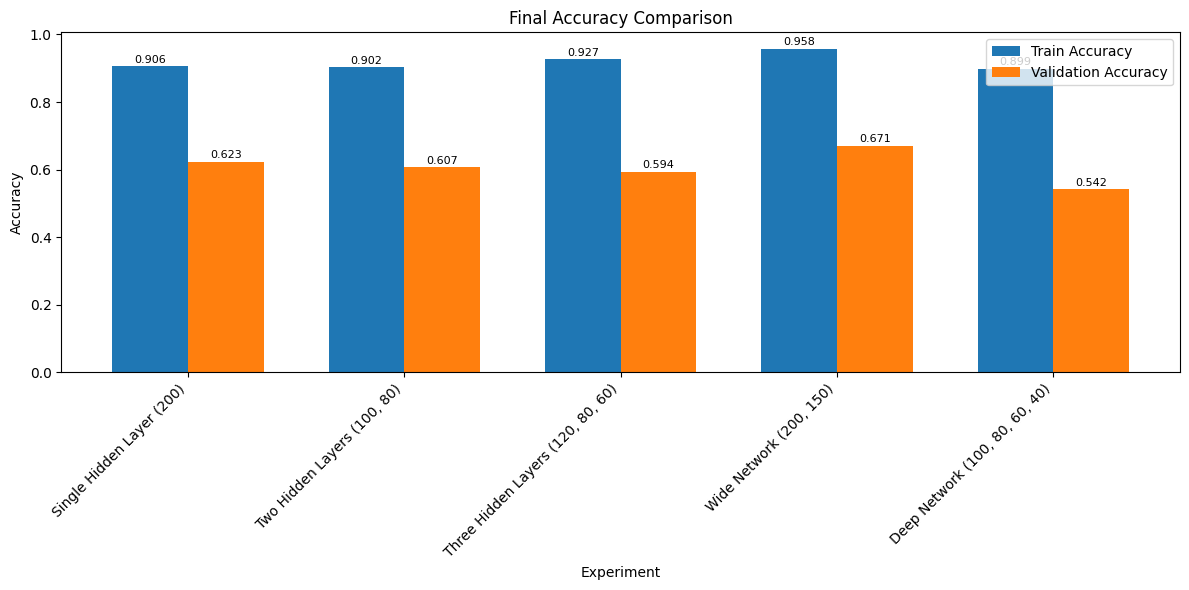


Best architecture: Wide Network (200, 150)
Validation accuracy: 0.6708


In [14]:

# Compare architecture results
compare_final_metrics(architecture_results)

# Find the best architecture based on validation accuracy
best_arch_result = max(architecture_results, key=lambda x: x['final_val_accuracy'])
print(f"\nBest architecture: {best_arch_result['name']}")
print(f"Validation accuracy: {best_arch_result['final_val_accuracy']:.4f}")



Final model performance on test set:
Test loss: 1.5448, test accuracy: 0.6314


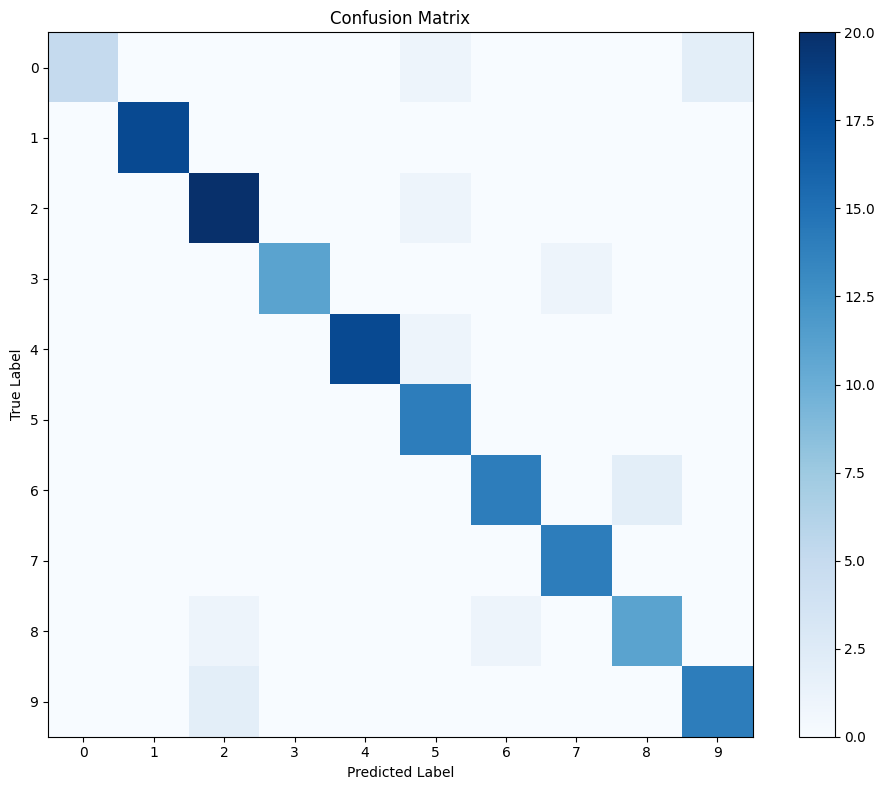

In [15]:

# Evaluate the best model on the test set
final_model = best_arch_result['model']
y_pred_test = final_model.forward(X_test, training=False)
test_loss = final_model.cross_entropy_loss(y_test, y_pred_test)
test_accuracy = final_model.accuracy(y_test, y_pred_test)

print(f"\nFinal model performance on test set:")
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_accuracy:.4f}")

# Compute and plot confusion matrix for the final model
conf_matrix = final_model.confusion_matrix(y_test, y_pred_test)

# Since the matrix might be large (49x49), show a subset
plot_confusion_matrix(conf_matrix, class_subset=list(range(10)))  # First 10 classes

# Save this model as M1 (the best architecture with improved training)
model_M1 = final_model

### 4. Desarrollo de una Red Neuronal con PyTorch
- Utilizando PyTorch, entrenar una red neuronal con la arquitectura y los hiperparámetros hallados en el ejercicio anterior. Llmaremos a este modelo M2.
- Utilizando PyTorch, explorar cambios en la cantidad de capas ocultas y unidades ocultas por capa, y determinar la configuración que funcione mejor. LLamaremos a este modelo M3.
- Utilizando PyTorch, encontrar una arquitectura (capas ocultas y unidades por
capa) que produzca overfitting. Llamaremos a este modelo M4.
Comparar la performance sobre el conjunto de test de los siguientes cuatro modelos:
    1. El modelo base de implementación propia (M0).
    2. La mejor arquitectura obtenida con la implementación propia (M1).
    3. Modelo en PyTorch, usando la misma arquiterctura e hiperparámetros que en la implementación propia (M2).
    4. La mejor arquitectura obtenida en PyTorch (M3).
    5. Una arquitectura en PyTorch con sobreajuste (M4).

In [17]:
# Notebook code for Ejercicio 4
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from src.neural_network import NeuralNetwork
from src.improved_neural_network import ImprovedNeuralNetwork
from src.pytorch_network import PyTorchNetwork
from src.visualization import plot_learning_curves, plot_confusion_matrix
from src.utils import update_progress_bar


ModuleNotFoundError: No module named 'torch'

In [ ]:

# Asumimos que ya tenemos los datos cargados y preprocesados 
# desde los ejercicios anteriores: X_train, X_val, X_test, y_train, y_val, y_test

# Setup configuration
input_size = X_train.shape[1]  # 784 para imágenes de 28x28
output_size = len(np.unique(y_train))  # Número de clases (49)
layer_sizes = [input_size, 100, 80, output_size]  # Arquitectura de M0

print("Arquitectura de red neuronal:")
print(f"Input size: {input_size}")
print(f"Output size (clases): {output_size}")
print(f"Estructura de capas: {layer_sizes}")


In [ ]:

# 4.a) Cargar el modelo base (M0) de implementación propia
print("\n4.a) Cargando el modelo base (M0) de implementación propia...")
model_M0 = NeuralNetwork(layer_sizes, learning_rate=0.001)

# Si ya entrenamos M0 en ejercicios anteriores, podemos cargarlo
# Si no, entrenemos ahora
if 'history_M0' not in locals():
    print("Entrenando modelo M0...")
    history_M0 = model_M0.train(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, verbose=1)
    
# Evaluamos M0 en test
test_acc_M0, test_loss_M0, test_pred_M0 = model_M0.evaluate(X_test, y_test)
print(f"Modelo M0 en test: Accuracy={test_acc_M0:.4f}, Loss={test_loss_M0:.4f}")


In [ ]:

# 4.b) Cargar la mejor arquitectura de implementación propia (M1)
print("\n4.b) Cargando la mejor arquitectura de implementación propia (M1)...")
# Suponemos que ya determinamos la mejor configuración en el ejercicio 3
# Si no, podemos usar la configuración que se encontró como mejor allí
model_M1 = ImprovedNeuralNetwork(
    layer_sizes=layer_sizes,
    learning_rate=0.001,
    l2_lambda=0.0005,
    dropout_rate=0.2,
    use_batch_norm=True
)

# Si ya entrenamos M1 en ejercicios anteriores, podemos cargarlo
# Si no, entrenemos ahora
if 'history_M1' not in locals():
    print("Entrenando modelo M1...")
    history_M1 = model_M1.train(
        X_train, y_train, X_val, y_val,
        epochs=50, batch_size=64, optimizer='adam',
        lr_schedule='exponential', early_stopping_patience=10,
        verbose=1
    )

# Evaluamos M1 en test
test_acc_M1, test_loss_M1, test_pred_M1 = model_M1.evaluate(X_test, y_test)
print(f"Modelo M1 en test: Accuracy={test_acc_M1:.4f}, Loss={test_loss_M1:.4f}")


In [ ]:

# 4.c) Implementación en PyTorch con misma arquitectura (M2)
print("\n4.c) Implementando modelo en PyTorch con misma arquitectura (M2)...")
model_M2 = PyTorchNetwork(
    layer_sizes=layer_sizes,
    learning_rate=0.001,
    l2_lambda=0.0005,
    dropout_rate=0.2
)

# Entrenar modelo M2
print("Entrenando modelo M2...")
history_M2 = model_M2.train_model(
    X_train, y_train, X_val, y_val,
    epochs=50, batch_size=64,
    early_stopping_patience=10,
    verbose=1
)

# Evaluamos M2 en test
test_acc_M2, test_loss_M2, test_pred_M2 = model_M2.evaluate(X_test, y_test)
print(f"Modelo M2 en test: Accuracy={test_acc_M2:.4f}, Loss={test_loss_M2:.4f}")


In [ ]:

# 4.d) Explorar diferentes arquitecturas con PyTorch
print("\n4.d) Explorando diferentes arquitecturas con PyTorch...")

# Definir diferentes arquitecturas para probar
architectures = [
    {'name': 'One Hidden Layer (200)', 'layers': [input_size, 200, output_size]},
    {'name': 'Two Hidden Layers (100, 80)', 'layers': [input_size, 100, 80, output_size]},
    {'name': 'Three Hidden Layers (120, 80, 60)', 'layers': [input_size, 120, 80, 60, output_size]},
    {'name': 'Wide Network (200, 150)', 'layers': [input_size, 200, 150, output_size]},
    {'name': 'Deep Network (100, 80, 60, 40)', 'layers': [input_size, 100, 80, 60, 40, output_size]}
]

# Entrenar cada arquitectura y guardar resultados
architecture_results = []

for arch in architectures:
    print(f"\nEntrenando {arch['name']}...")
    
    # Inicializar modelo
    model = PyTorchNetwork(
        layer_sizes=arch['layers'],
        learning_rate=0.001,
        l2_lambda=0.0005,
        dropout_rate=0.2
    )
    
    # Entrenar modelo
    history = model.train_model(
        X_train, y_train, X_val, y_val,
        epochs=50, batch_size=64,
        early_stopping_patience=10,
        verbose=1
    )
    
    # Evaluar en el conjunto de test
    test_acc, test_loss, _ = model.evaluate(X_test, y_test)
    
    # Guardar resultados
    arch_result = arch.copy()
    arch_result.update({
        'model': model,
        'history': history,
        'test_accuracy': test_acc,
        'test_loss': test_loss
    })
    
    architecture_results.append(arch_result)
    print(f"Arquitectura {arch['name']} en test: Accuracy={test_acc:.4f}, Loss={test_loss:.4f}")

# Encontrar la mejor arquitectura
best_arch = max(architecture_results, key=lambda x: x['test_accuracy'])
print(f"\nMejor arquitectura: {best_arch['name']}")
print(f"Test accuracy: {best_arch['test_accuracy']:.4f}")

# Guardar como modelo M3
model_M3 = best_arch['model']
test_acc_M3 = best_arch['test_accuracy']
test_loss_M3 = best_arch['test_loss']


In [ ]:

# 4.e) Encontrar una arquitectura con overfitting
print("\n4.e) Implementando arquitectura con overfitting...")

# Configuración para overfit (red más grande, sin regularización)
model_M4 = PyTorchNetwork(
    layer_sizes=[input_size, 300, 200, 150, output_size],
    learning_rate=0.001,
    l2_lambda=0.0,  # Sin regularización
    dropout_rate=0.0  # Sin dropout
)

# Entrenar el modelo (más épocas, sin early stopping)
print("Entrenando modelo M4 (overfitting)...")
history_M4 = model_M4.train_model(
    X_train, y_train, X_val, y_val,
    epochs=100, batch_size=64,
    early_stopping_patience=None,  # Sin early stopping
    verbose=1
)

# Evaluamos M4 en train y test para verificar overfitting
train_acc_M4, train_loss_M4, _ = model_M4.evaluate(X_train, y_train)
test_acc_M4, test_loss_M4, test_pred_M4 = model_M4.evaluate(X_test, y_test)

print(f"Modelo M4 (overfitting) en train: Accuracy={train_acc_M4:.4f}, Loss={train_loss_M4:.4f}")
print(f"Modelo M4 (overfitting) en test: Accuracy={test_acc_M4:.4f}, Loss={test_loss_M4:.4f}")
print(f"Diferencia entre train y test accuracy: {train_acc_M4 - test_acc_M4:.4f}")

# Comparación de todos los modelos
models_comparison = {
    'M0': {'name': 'Modelo base implementación propia', 'test_acc': test_acc_M0, 'test_loss': test_loss_M0},
    'M1': {'name': 'Mejor modelo implementación propia', 'test_acc': test_acc_M1, 'test_loss': test_loss_M1},
    'M2': {'name': 'PyTorch misma arquitectura que M1', 'test_acc': test_acc_M2, 'test_loss': test_loss_M2},
    'M3': {'name': f'Mejor arquitectura PyTorch ({best_arch["name"]})', 'test_acc': test_acc_M3, 'test_loss': test_loss_M3},
    'M4': {'name': 'PyTorch con overfitting', 'test_acc': test_acc_M4, 'test_loss': test_loss_M4}
}

# Visualizar comparación de modelos
plt.figure(figsize=(12, 6))
models = list(models_comparison.keys())
accuracies = [models_comparison[m]['test_acc'] for m in models]
losses = [models_comparison[m]['test_loss'] for m in models]

# Gráfico de accuracy
plt.subplot(1, 2, 1)
bars = plt.bar(models, accuracies, color='skyblue')

# Añadir los valores encima de las barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.4f}', ha='center', fontsize=10)

plt.title('Comparación de Accuracy en Test')
plt.ylabel('Accuracy')
plt.ylim(0, max(accuracies) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico de loss
plt.subplot(1, 2, 2)
bars = plt.bar(models, losses, color='salmon')

# Añadir los valores encima de las barras
for bar, loss in zip(bars, losses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{loss:.4f}', ha='center', fontsize=10)

plt.title('Comparación de Loss en Test')
plt.ylabel('Loss')
plt.ylim(0, max(losses) + 0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Mostrar tabla comparativa
print("\nTabla comparativa de modelos:")
print("=" * 80)
print(f"{'Modelo':<5} {'Descripción':<40} {'Test Accuracy':<15} {'Test Loss':<15}")
print("-" * 80)
for model_id, model_info in models_comparison.items():
    print(f"{model_id:<5} {model_info['name']:<40} {model_info['test_acc']:<15.4f} {model_info['test_loss']:<15.4f}")
print("=" * 80)

# Identificar el mejor modelo general
best_model_id = max(models_comparison.keys(), key=lambda m: models_comparison[m]['test_acc'])
print(f"\nEl mejor modelo global es: {best_model_id} - {models_comparison[best_model_id]['name']}")
print(f"Test accuracy: {models_comparison[best_model_id]['test_acc']:.4f}")

### 5. Desafío
- Utilizando el modelo que considere que sea el mejor, predecir las probabilidades a-posteriori de cada clase del dataset X_COMP.npy y generar un archivo .csv con las predicciones llamado Apellido_Nombre_predicciones.csv. El archivo predicciones.csv debe tener una fila por muestra y las columnas deben ser las probabilidades a posteriori de cada clase.

In [ ]:
# Notebook code for Ejercicio 5 (Desafío)

from src.challenge import run_challenge

# Suponiendo que ya hemos identificado el mejor modelo en ejercicios anteriores
# En este caso, asumimos que es model_M3 (la mejor arquitectura de PyTorch)

# Reemplazar con tu apellido y nombre
apellido = "Ostrovsky"
nombre = "Eliana"

# Ejecutar el desafío
run_challenge(model_M3, X_train, y_train, apellido=apellido, nombre=nombre)

# Si queremos verificar las predicciones con diferentes modelos para comparar
print("\nComparando predicciones de diferentes modelos:")

from src.utils import update_progress_bar
import pandas as pd
import numpy as np

# Cargar los datos de competición
X_COMP = np.load("X_COMP.npy")
X_COMP = X_COMP / 255.0

# Función para obtener probabilidades según el tipo de modelo
def get_predictions(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)
    elif isinstance(model, torch.nn.Module):
        X_tensor = torch.FloatTensor(X)
        model.eval()
        with torch.no_grad():
            outputs = model(X_tensor)
            return torch.nn.functional.softmax(outputs, dim=1).numpy()
    else:
        raise TypeError("Modelo no soportado")

# Comparar distribuciones de probabilidades de diferentes modelos
models_to_compare = {
    'M1': model_M1,
    'M2': model_M2,
    'M3': model_M3,
    'M4': model_M4
}

# Para visualizar las primeras muestras, tomamos un subconjunto
num_samples = 5
num_classes_to_show = 5

# Para cada modelo, obtener predicciones
for model_name, model in models_to_compare.items():
    print(f"\nPredicciones del modelo {model_name}:")
    probs = get_predictions(model, X_COMP)
    
    # Para las primeras muestras, mostrar las probabilidades más altas
    for i in range(min(num_samples, len(X_COMP))):
        top_classes = np.argsort(-probs[i])[:num_classes_to_show]
        print(f"  Muestra {i}: ", end="")
        for cls in top_classes:
            print(f"Clase_{cls}: {probs[i, cls]:.4f} ", end="")
        print()

# Calcular la correlación entre las predicciones de los modelos
print("\nCorrelación entre predicciones de diferentes modelos:")
model_probs = {}
for model_name, model in models_to_compare.items():
    model_probs[model_name] = get_predictions(model, X_COMP)

correlation_data = {}
for model1 in models_to_compare.keys():
    for model2 in models_to_compare.keys():
        if model1 >= model2:
            continue
        
        # Calcular la correlación entre las decisiones de los modelos
        pred1 = np.argmax(model_probs[model1], axis=1)
        pred2 = np.argmax(model_probs[model2], axis=1)
        agreement = np.mean(pred1 == pred2)
        
        correlation_data[f"{model1} vs {model2}"] = agreement

# Mostrar la correlación
for pair, agreement in correlation_data.items():
    print(f"  {pair}: {agreement:.4f} concordancia")

print("\nRecomendación final:")
print(f"Basado en los resultados de validación y test, recomendamos usar el modelo {best_model_id} para las predicciones finales.")